# SmartAd-AB-Testing-Analysis
#### 评估不同投放策略对用户转化率的影响
## 一、实验背景
### 1.商业背景：
#### 商家为了提高广告的点击率，设计了全新的智能广告，并以此开展A/B test，一组用户展示旧广告，一组展示新广告。
### 2.实验方式
#### 通过A/B test的实验结果分析，判断新版广告是否会影响用户对于广告的点击率
#### 原假设：Hₒ: p = pₒ - 两组广告的成功率没有显著差异
#### 备择假设：Hₐ: p ≠ pₒ - 两组广告的成功率没有显著差异 ，采用双尾检验
#### 置信水平：95% (α=0.05)
#### p 和 pₒ 分别代表新版广告与旧版广告的转化率

In [3]:
import pandas as pd
import numpy as np

import scipy.stats as stats
from scipy.stats import norm

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline

In [8]:
df = pd.read_csv('./AdSmartABdata - AdSmartABdata.csv')

In [10]:
df.head()

,auction_id,experiment,date,hour,device_make,platform_os,browser,yes,no
0,0008ef63-77a7-448b-bd1e-075f42c55e39,exposed,2020-07-10,8,Generic Smartphone,6,Chrome Mobile,0,0
1,000eabc5-17ce-4137-8efe-44734d914446,exposed,2020-07-07,10,Generic Smartphone,6,Chrome Mobile,0,0
2,0016d14a-ae18-4a02-a204-6ba53b52f2ed,exposed,2020-07-05,2,E5823,6,Chrome Mobile WebView,0,1
3,00187412-2932-4542-a8ef-3633901c98d9,control,2020-07-03,15,Samsung SM-A705FN,6,Facebook,0,0
4,001a7785-d3fe-4e11-a344-c8735acacc2c,control,2020-07-03,15,Generic Smartphone,6,Chrome Mobile,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8077 entries, 0 to 8076
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   auction_id   8077 non-null   object
 1   experiment   8077 non-null   object
 2   date         8077 non-null   object
 3   hour         8077 non-null   int64 
 4   device_make  8077 non-null   object
 5   platform_os  8077 non-null   int64 
 6   browser      8077 non-null   object
 7   yes          8077 non-null   int64 
 8   no           8077 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 568.0+ KB


In [11]:
df.describe()

,hour,platform_os,yes,no
count,8077.000000,8077.000000,8077.000000,8077.000000
mean,11.615080,5.947134,0.070818,0.083075
std,5.734879,0.224333,0.256537,0.276013
min,0.000000,5.000000,0.000000,0.000000
25%,7.000000,6.000000,0.000000,0.000000
50%,13.000000,6.000000,0.000000,0.000000
75%,15.000000,6.000000,0.000000,0.000000
max,23.000000,7.000000,1.000000,1.000000


In [16]:
df.isnull().sum()

auction_id     0
experiment     0
date           0
hour           0
device_make    0
platform_os    0
browser        0
yes            0
no             0
dtype: int64

In [17]:
df.shape

(8077, 9)

In [18]:
df.columns

Index(['auction_id', 'experiment', 'date', 'hour', 'device_make',
       'platform_os', 'browser', 'yes', 'no'],
      dtype='object')

In [19]:
# Set up the format and styles for plots globally
sns.set_style('white')
plt.rc('axes', titlesize=12)
plt.rc('axes', labelsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('legend', fontsize=10)
plt.rc('font', size=10)

In [20]:
num_duplicates = sum(df.duplicated(subset=['auction_id']))

print(f'Amount of duplicates: {num_duplicates}')

Amount of duplicates: 0


In [21]:
def get_response(row):
    '''
    Create response column with ecnoded response values
    :param row: list of ['yes', 'no'] columns of pandas dataframe
    
    '''
    
    if row[0] == 1:
        res = 'yes'
    elif row[1] == 1:
        res = 'no'
    else:
        res = 'no response'
        
    return res

In [22]:
def get_category_percent(row, decimal=1):
    '''
    Get percent of value distributed amoung colums
    :param row: list of columns from pandas dataframe
    '''
    
    return round(row/max(row)*100, decimal)

/var/folders/7n/l9y5ltgj7k5dxwg189xm0q980000gn/T/ipykernel_15343/2475865327.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row[0] == 1:
/var/folders/7n/l9y5ltgj7k5dxwg189xm0q980000gn/T/ipykernel_15343/2475865327.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif row[1] == 1:


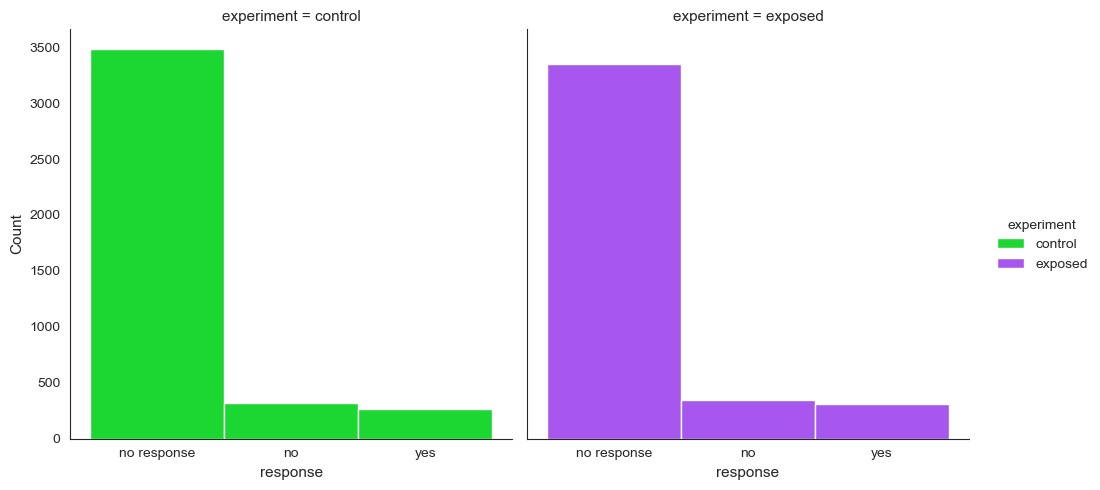

response %,yes,no,no response
experiment,,,
control,6.5,7.9,85.6
exposed,7.7,8.7,83.6


In [23]:
df['response'] = df[['yes', 'no']].apply(get_response, axis=1)

sns.displot(df.sort_values(by='experiment'), x='response', 
            col='experiment', hue='experiment', 
            palette=['#1CD631','#A757EE'], alpha=1)

plt.show()

df_response = pd.pivot_table(data=df, index='experiment', columns='response', aggfunc='count')['auction_id']

df_response['total'] = df_response.apply(sum, axis=1)

df_response = df_response.apply(get_category_percent, axis=1)

df_response.columns.name = 'response %'

df_response = df_response[['yes', 'no', 'no response']]

display(df_response)

In [24]:
df = df[(df['yes'] == 1) | (df['no'] == 1)]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1243 entries, 2 to 8071
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   auction_id   1243 non-null   object
 1   experiment   1243 non-null   object
 2   date         1243 non-null   object
 3   hour         1243 non-null   int64 
 4   device_make  1243 non-null   object
 5   platform_os  1243 non-null   int64 
 6   browser      1243 non-null   object
 7   yes          1243 non-null   int64 
 8   no           1243 non-null   int64 
 9   response     1243 non-null   object
dtypes: int64(4), object(6)
memory usage: 106.8+ KB


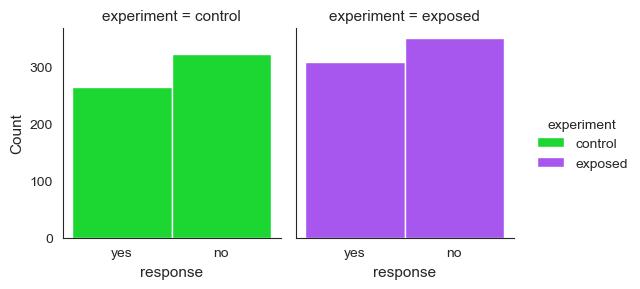

response %,yes,no
experiment,,
control,45.1,54.9
exposed,46.9,53.1


In [25]:
sns.displot(df.sort_values(by='experiment'), x='response', 
            col='experiment', hue='experiment', 
            palette=['#1CD631','#A757EE'], alpha=1, height=3, aspect=0.9)

plt.show()

df_response = pd.pivot_table(data=df, index='experiment', columns='response', aggfunc='count')['auction_id']

df_response['total'] = df_response.apply(sum, axis=1)

df_response = df_response.apply(get_category_percent, axis=1)

df_response.columns.name = 'response %'

df_response = df_response[['yes', 'no']]

display(df_response)

/var/folders/7n/l9y5ltgj7k5dxwg189xm0q980000gn/T/ipykernel_15343/3406344150.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df.sort_values(by='experiment'), x='experiment',


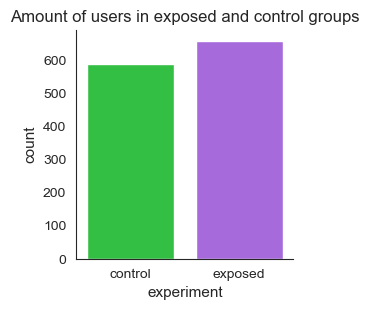

Percent of users in control group: 47.1%
Percent of users in exposed group: 52.9%


In [26]:
sns.catplot(data=df.sort_values(by='experiment'), x='experiment', 
            kind='count', height=3, palette=['#1CD631','#A757EE'])\
            .set(title='Amount of users in exposed and control groups')
plt.show()

print('Percent of users in control group: {:.1%}'\
      .format(len(df[df['experiment']=='control'])/len(df)))
print('Percent of users in exposed group: {:.1%}'\
      .format(len(df[df['experiment']=='exposed'])/len(df)))

In [27]:
print('First date of experiment: {}'.format(df['date'].min()))
print('Last date of experiment:  {}'.format(df['date'].max()))

First date of experiment: 2020-07-03
Last date of experiment:  2020-07-10


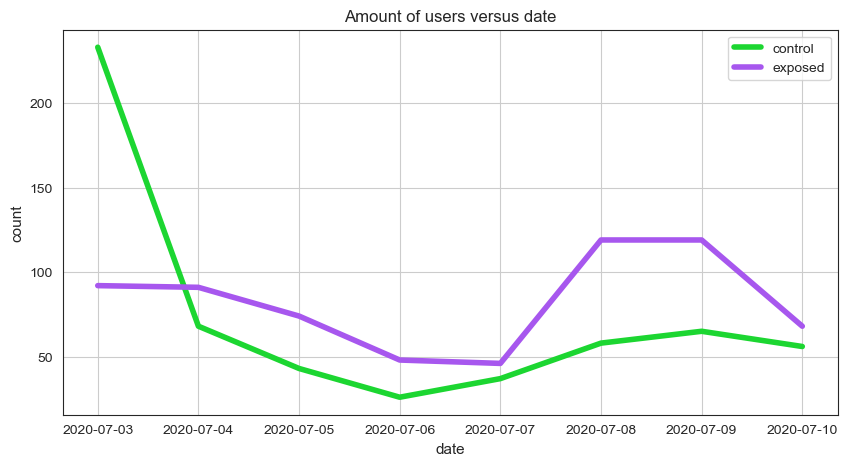

In [28]:
fig, ax = plt.subplots(figsize=(10,5))

g = sns.lineplot(data=df.groupby(['experiment', 'date'])['date'].count()['control'], 
                ax=ax, label='control', color='#1CD631', linewidth = 4)
g = sns.lineplot(data=df.groupby(['experiment', 'date'])['date'].count()['exposed'], 
                ax=ax, label='exposed', color='#A757EE', linewidth = 4)

ax.grid(True)
ax.set_ylabel('count')
ax.set_title('Amount of users versus date')
plt.show()

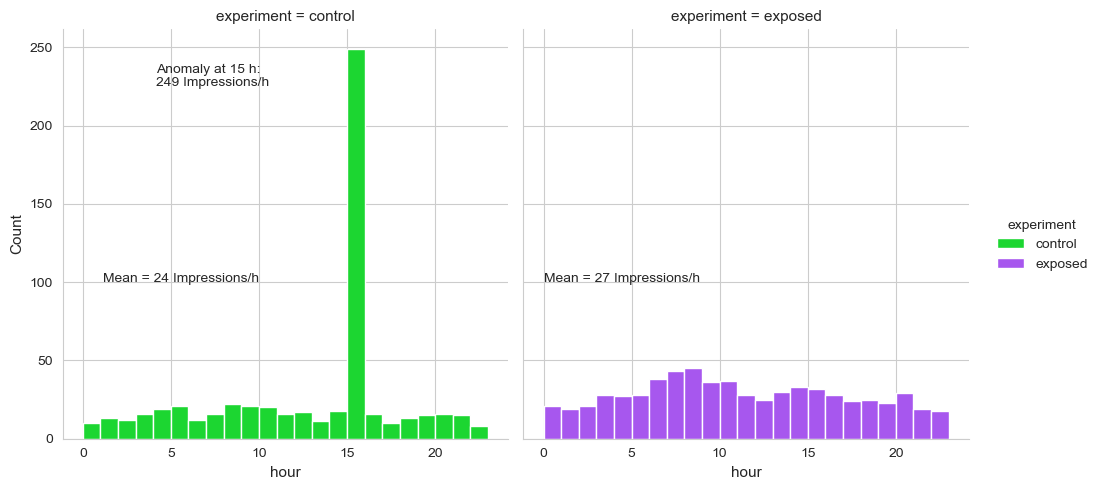

In [29]:
sns.set_style("whitegrid")

sns.displot(df.sort_values(by='experiment'), x='hour', col='experiment', 
            bins=range(24), hue='experiment', 
            palette=['#1CD631','#A757EE'], alpha=1)

plt.text(-25, 100, "Mean = {:.0f} Impressions/h"\
         .format(df[df['experiment']=='control']\
                 .groupby('hour')['experiment'].count().mean()))

plt.text(-22, 225, "Anomaly at 15 h:\n{:.0f} Impressions/h"\
         .format(df[df['experiment']=='control']\
                 .groupby('hour')['experiment'].count().max()))

plt.text(0, 100, "Mean = {:.0f} Impressions/h"\
         .format(df[df['experiment']=='exposed']\
                 .groupby('hour')['experiment'].count().mean()))


plt.show()

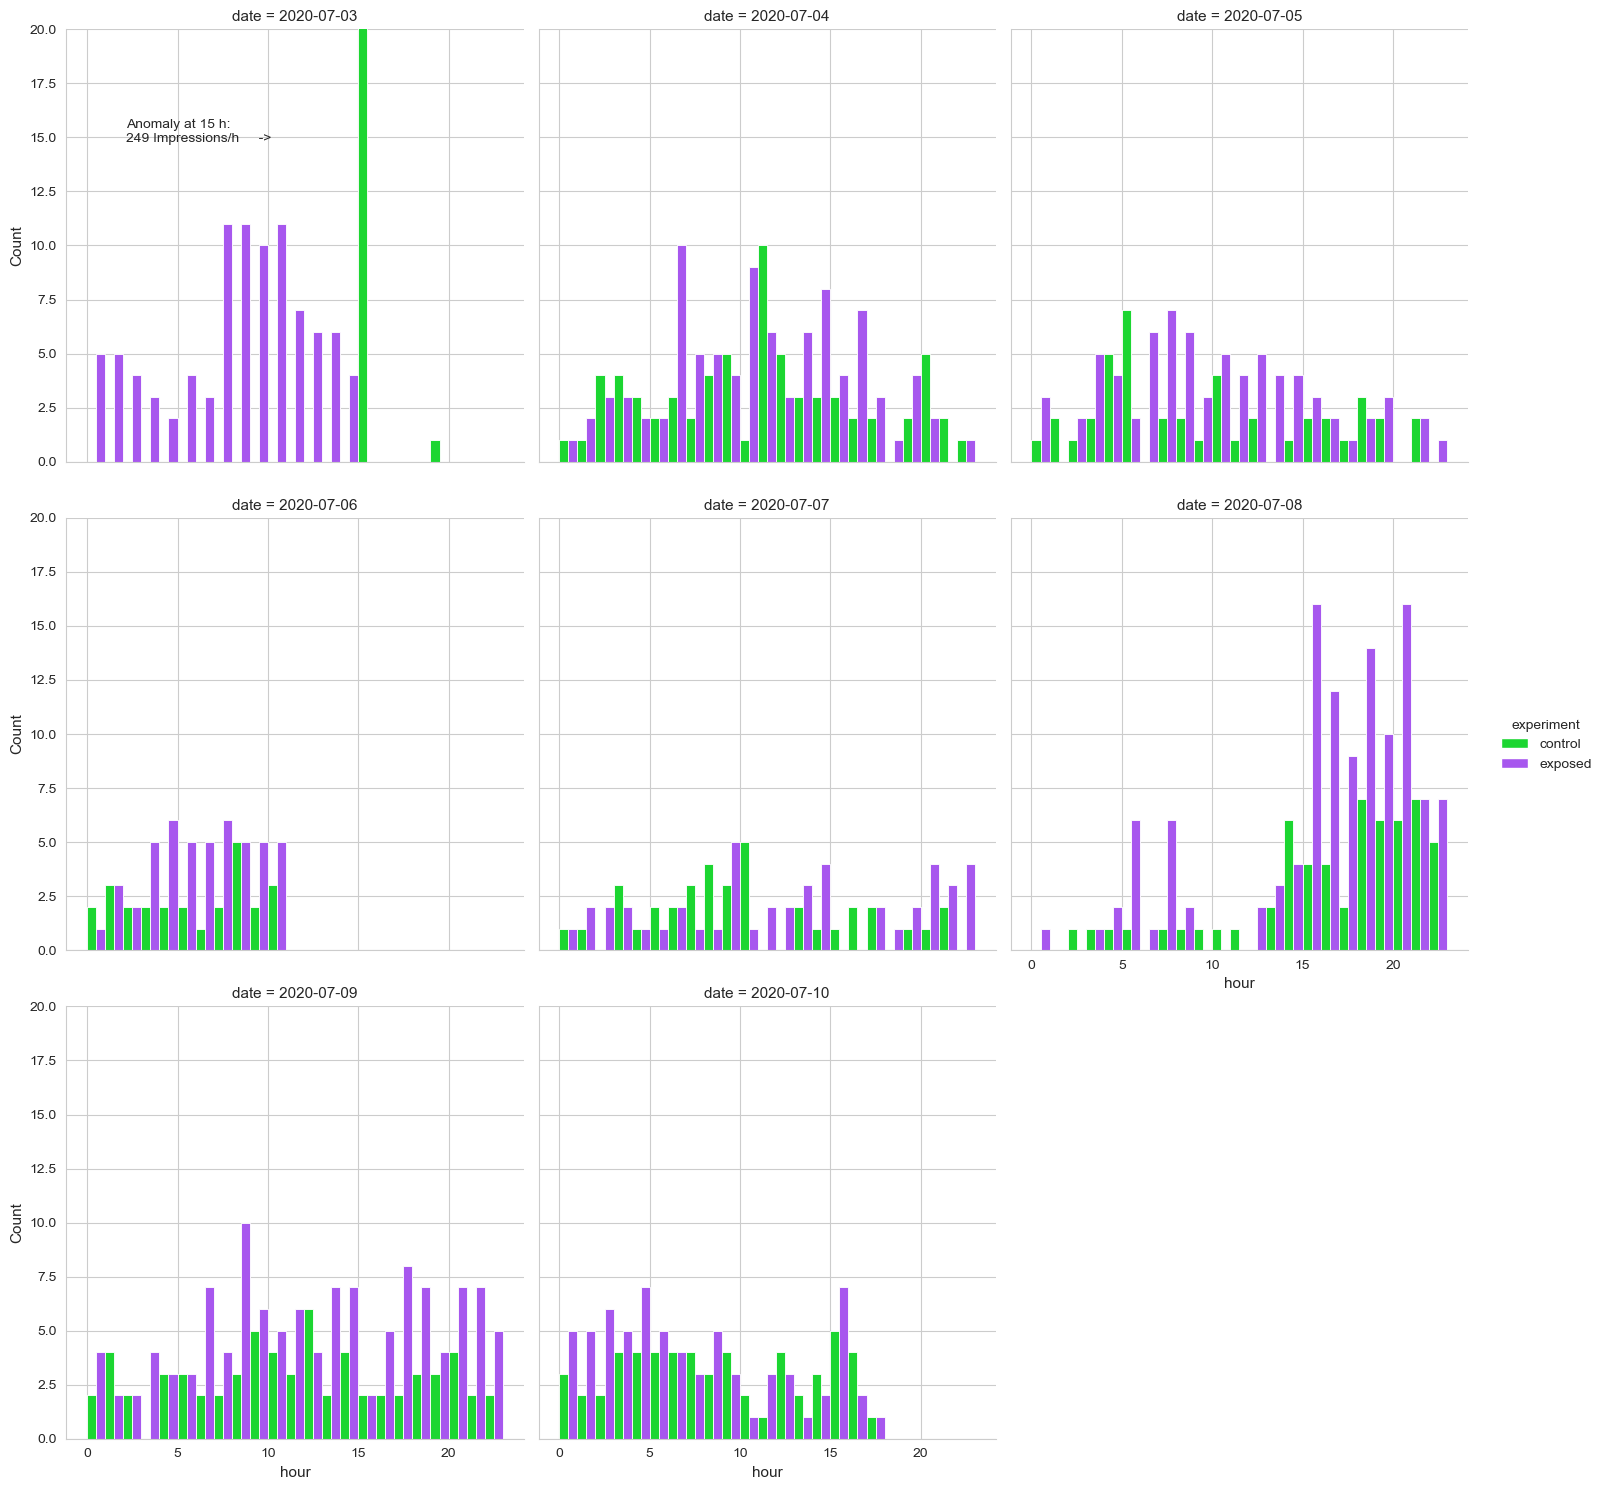

In [30]:
sns.set_style("whitegrid")

sns.displot(df.sort_values(by=['date','experiment']), x='hour', col='date', bins=range(24), 
            hue='experiment', palette=['#1CD631','#A757EE'], alpha=1,
            multiple="dodge", col_wrap=3, facet_kws=dict(sharey=True))
plt.ylim([0, 20])

plt.text(-24, 60, "Anomaly at 15 h:\n{:.0f} Impressions/h     ->"\
         .format(df[df['experiment']=='control']\
                 .groupby('hour')['experiment'].count().max()))
plt.show()